<a href="https://colab.research.google.com/github/obedglanson/senior_project_slc6a14/blob/main/structural_val.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install biopython

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 78.3 MB/s eta 0:00:00


Running Strict Structural Validation on B2OUT_3.pdb

[Clash Analysis]
Severe Steric Clashes (< 2.2 Å): 12
Top 5 worst clashes (Corrected Chain IDs):
  A:ALA53 (O) <--> B:NA1 (NA): 1.802 Å
  A:GLN436 (OE1) <--> A:ARG447 (NH2): 1.890 Å
  A:GLN211 (OE1) <--> A:GLN216 (NE2): 2.101 Å
  A:ASN504 (OD1) <--> A:ARG526 (NH1): 2.133 Å
  A:ARG36 (NH1) <--> A:ASP437 (OD1): 2.140 Å

[Ramachandran Analysis]
Successfully extracted 640 backbone dihedral angles.
Estimated severe geometric outliers (excluding Glycine): 0 residues (0.0%)
  Pass: Backbone geometry is within acceptable bounds (< 2% outliers).


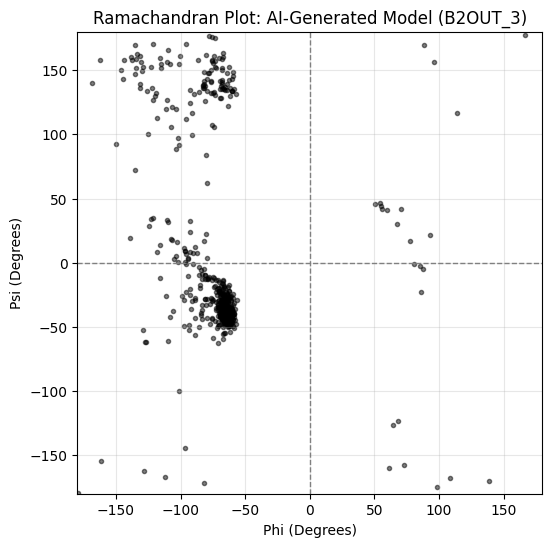

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from Bio.PDB import PDBParser, NeighborSearch, Selection, PPBuilder
import warnings
from Bio import BiopythonWarning

# Suppress minor PDB formatting warnings
warnings.simplefilter('ignore', BiopythonWarning)

def validate_structure(pdb_file_path, clash_threshold=2.2):
    print(f"Running Strict Structural Validation on {pdb_file_path}")
    parser = PDBParser()
    try:
        structure = parser.get_structure("Model", pdb_file_path)
    except FileNotFoundError:
        print(f"Error: {pdb_file_path} not found. Please upload it to Colab.")
        return


    # 1. Rigorous Steric Clash Detection

    # Extract heavy atoms only
    atoms = [a for a in Selection.unfold_entities(structure, 'A') if a.element != 'H']
    ns = NeighborSearch(atoms)
    clashes = []

    for atom in atoms:
        neighbors = ns.search(atom.coord, clash_threshold)
        for neighbor in neighbors:
            if id(atom) < id(neighbor):
                res1 = atom.get_parent()
                res2 = neighbor.get_parent()
                chain1 = res1.get_parent()
                chain2 = res2.get_parent()

                # Bypass 1: Exclude atoms in the same residue or sequentially adjacent residues ON THE SAME CHAIN
                if chain1.get_id() == chain2.get_id() and abs(res1.get_id()[1] - res2.get_id()[1]) <= 1:
                    continue

                # Bypass 2: Exclude physiological Disulfide Bridges (CYS SG - CYS SG are naturally ~2.04 Å apart)
                if atom.get_name() == 'SG' and neighbor.get_name() == 'SG' and res1.get_resname() == 'CYS' and res2.get_resname() == 'CYS':
                    continue

                distance = np.linalg.norm(atom.coord - neighbor.coord)
                clashes.append((atom, neighbor, distance))

    print(f"\n[Clash Analysis]")
    print(f"Severe Steric Clashes (< {clash_threshold} Å): {len(clashes)}")
    if len(clashes) > 0:
        print("Top 5 worst clashes (Corrected Chain IDs):")
        clashes.sort(key=lambda x: x[2])
        for i in range(min(5, len(clashes))):
            a1, a2, dist = clashes[i]

            # dynamically extract exact chain IDs for the specific clashing atoms
            c1_true = a1.get_parent().get_parent().get_id()
            c2_true = a2.get_parent().get_parent().get_id()

            print(f"  {c1_true}:{a1.get_parent().get_resname()}{a1.get_parent().get_id()[1]} ({a1.get_name()}) <--> "
                  f"{c2_true}:{a2.get_parent().get_resname()}{a2.get_parent().get_id()[1]} ({a2.get_name()}): {dist:.3f} Å")
    else:
        print("  Pass: No severe heavy-atom steric clashes detected.")


    # 2. Ramachandran Dihedral Analysis

    ppb = PPBuilder()
    phi_psi_angles = []
    outliers = 0
    total_residues = 0

    for pp in ppb.build_peptides(structure):
        # Extract residues alongside their angles to verify amino acid type
        for residue, (phi, psi) in zip(pp, pp.get_phi_psi_list()):
            if phi is not None and psi is not None:
                phi_deg = np.degrees(phi)
                psi_deg = np.degrees(psi)
                phi_psi_angles.append((phi_deg, psi_deg))
                total_residues += 1

                res_name = residue.get_resname()

                # Bypass 3: Glycine is achiral and permitted in the positive-phi region.
                if res_name != 'GLY':
                    if phi_deg > 0 and psi_deg < -50:
                        outliers += 1

    if not phi_psi_angles:
        print("\n[Ramachandran Analysis] Error: Could not extract backbone dihedrals.")
        return

    phis, psis = zip(*phi_psi_angles)

    print(f"\n[Ramachandran Analysis]")
    print(f"Successfully extracted {total_residues} backbone dihedral angles.")

    outlier_percentage = (outliers / total_residues) * 100
    print(f"Estimated severe geometric outliers (excluding Glycine): {outliers} residues ({outlier_percentage:.1f}%)")
    if outlier_percentage < 2.0:
        print("  Pass: Backbone geometry is within acceptable bounds (< 2% outliers).")
    else:
        print("  Warning: High number of outliers. The model may have collapsed or twisted unnaturally.")

    # Plotting
    plt.figure(figsize=(6,6))
    plt.scatter(phis, psis, marker='.', color='black', alpha=0.5)
    plt.xlim(-180, 180)
    plt.ylim(-180, 180)
    plt.axhline(0, color='gray', lw=1, linestyle='--')
    plt.axvline(0, color='gray', lw=1, linestyle='--')
    plt.xlabel('Phi (Degrees)')
    plt.ylabel('Psi (Degrees)')
    plt.title('Ramachandran Plot: AI-Generated Model (B2OUT_3)')
    plt.grid(True, alpha=0.3)
    plt.show()

# Execution
validate_structure("B2OUT_3.pdb")